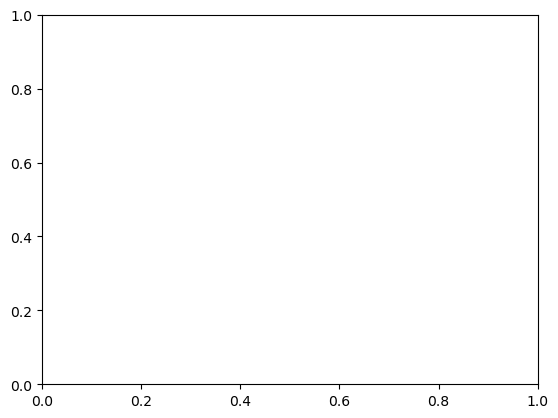

In [3]:
import numpy as np
from scipy.stats import expon
import matplotlib.pyplot as plt
fig, ax = plt.subplots()

## Случайная величина имеет экспоненциальный закон распределения. Сгенерируйте выборку объема n = 25. 

In [4]:
lb, ub = expon.support()

In [41]:
n = 25

In [6]:
r = expon.rvs(size=n)
print(r) #нет смысла считать моду, тк числа уникальны до 8-ого знака после запятой 

[2.34384394 0.76057751 2.27393381 0.18545571 1.01849206 1.23418261
 0.02074039 0.03864978 0.11570922 1.55898738 1.2500972  1.67381178
 2.21532963 0.01152631 0.31862649 0.55316719 0.86170502 0.18524236
 0.79989327 0.6742447  1.28465649 0.97282905 2.2165433  2.59191697
 1.00871994]


## a)Определить по выборке моду, медиану, размах, оценку коэффициента ассиметрии

In [27]:
r.sort()
print(r)
print(" ")
print(r[12]) #медиана будет 13 элементом

[0.01152631 0.02074039 0.03864978 0.11570922 0.18524236 0.18545571
 0.31862649 0.55316719 0.6742447  0.76057751 0.79989327 0.86170502
 0.97282905 1.00871994 1.01849206 1.23418261 1.2500972  1.28465649
 1.55898738 1.67381178 2.21532963 2.2165433  2.27393381 2.34384394
 2.59191697]
 
0.9728290468711162


In [16]:
q2 = np.median(r)
print(q2)

0.9728290468711162


In [23]:
print((r[5] + r[6]) / 2, (r[-6] + r[-7]) /2)

0.25204109914765926 1.6163995797969974


In [25]:
q1 = np.quantile(r, 0.25)
q3 = np.quantile(r, 0.75)
print(q1, q3)

0.31862648592268966 1.558987379367383


### Python по умолчанию считает квартили иначе, нежели мы на лекции. Диапазон индексов [0,24].

q1 = 0.25 * 24 = 6 --> q1 = r[6]

q3 = 0.75 * 24 = 18 --> q3 = r[18]

### можем задать ему метод вычисления, как на лекциях

In [29]:
q1_lec = np.quantile(r, 0.25, method="weibull")
q3_lec = np.quantile(r, 0.75, method="weibull")
print(q1_lec, q3_lec)

0.25204109914765926 1.6163995797969974


In [31]:
l = r[-1] - r[0] #размах выборки
print(l)

2.5803906633746103


In [37]:
k = 3
m_3 = np.mean((r - r.mean())**k) #оценка k-ого центрального момента
m_2 = np.mean((r - r.mean())**(k-1))

gamma = m_3 / (m_2 ** (3/2))
print(gamma)

0.4363646175516664


In [42]:
y = [i/n for i in range(n)]
print(y)

[0.0, 0.04, 0.08, 0.12, 0.16, 0.2, 0.24, 0.28, 0.32, 0.36, 0.4, 0.44, 0.48, 0.52, 0.56, 0.6, 0.64, 0.68, 0.72, 0.76, 0.8, 0.84, 0.88, 0.92, 0.96]


## График эмперической функции распределения

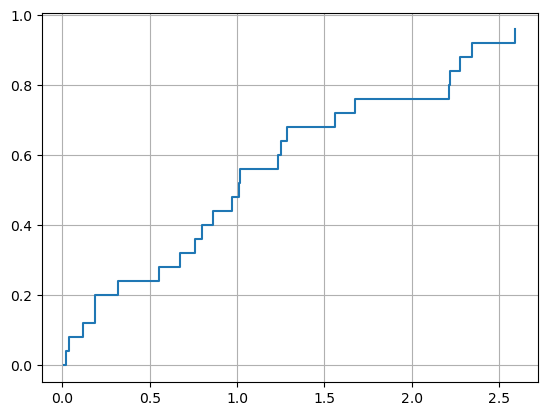

In [43]:
plt.step(r, y, where="post")
plt.grid()
plt.show()

## Гистограмма

###  Те правила построения гистограммы, которые нам давали на лекции, описывают гистограмму плотности. Высота столбца рассчитывается по правилу: h = count / n * delta, где count - количество элементов выборки, попавших в delta

### Главное свойство такой гистограммы: площадь всех её столбцов в сумме равна 1. Это позволяет напрямую сравнивать гистограмму выборки с графиком теоретической плотности вероятности.

In [54]:
k = 1 + np.log2(n)
delta = (l/k).round(1)
print(delta)

0.5


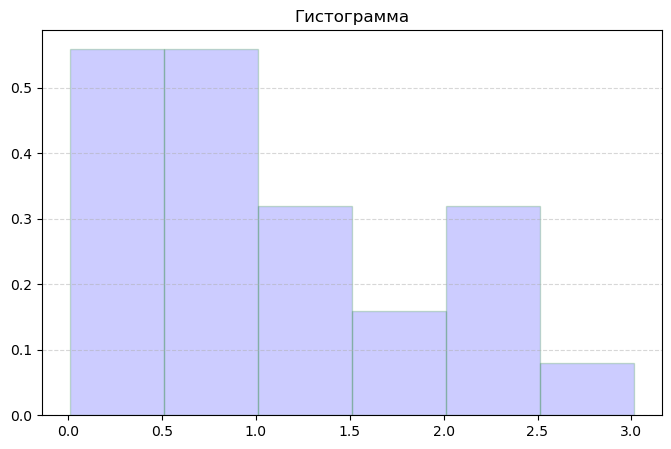

In [61]:
bins = np.arange(r.min(), r.max() + delta, delta)

plt.figure(figsize=(8, 5))
plt.hist(r, bins=bins, density=True ,edgecolor='green', color='blue', alpha=0.2)

plt.title('Гистограмма')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

## Boxplot

### boxplot -иллюстрация, которая строится по выборке по следующим правилам:
- границы ящика определяются по первому и третьему квартилю
- также отмечается второй квартиль (медиана)
- вычисляется межквартильное расстояние (IQR) по формуле = q3 - q1
- откладываются "усики" вправо и влево: q1 - 1.5 IQR; q3 + 1.5 IQR
- всё что вышло за "усики" - потенциально считаются выбросами


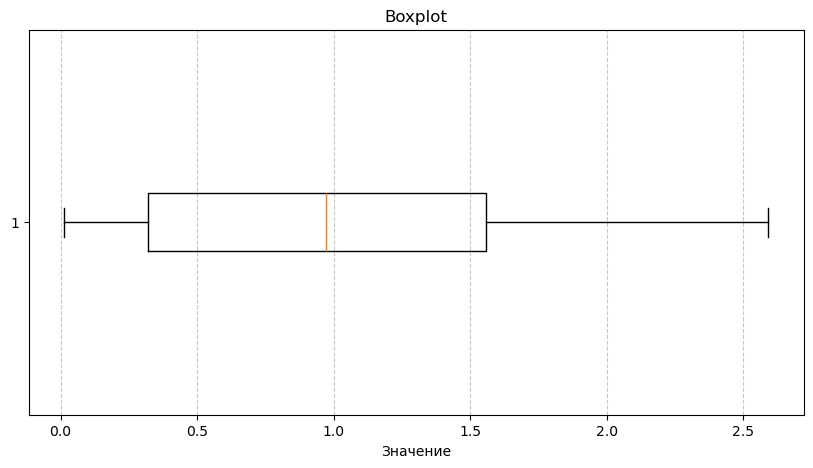

In [66]:
plt.figure(figsize=(10,5))
plt.boxplot(r, vert=False)

plt.title('Boxplot')
plt.xlabel('Значение')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()